In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

PyTorch Version: 2.9.1
CUDA Available: False


In [2]:
import torch
if torch.cuda.is_available():
    print(f"Memory allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")

In [3]:
import numpy as np

def lorenz_system(state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return np.array([dxdt, dydt, dzdt])

def rk4_step(state, dt):
    k1 = lorenz_system(state)
    k2 = lorenz_system(state + k1 * dt / 2)
    k3 = lorenz_system(state + k2 * dt / 2)
    k4 = lorenz_system(state + k3 * dt)
    return state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
dt = 0.01
n_steps = 100000
data = np.zeros((n_steps, 3))
current_state = np.array([1.0, 1.0, 1.0])
for i in range(n_steps):
    data[i] = current_state
    current_state = rk4_step(current_state, dt)
dataset = torch.tensor(data, dtype=torch.float32)
mean = dataset.mean(dim=0)
std = dataset.std(dim=0)
dataset_norm = (dataset - mean) / std

def create_windows(data, L=50):
    X = torch.stack([data[i:i+L] for i in range(len(data)-L)])
    y = data[L:]
    return X, y
X_windows, y_windows = create_windows(dataset_norm)
split = int(0.8 * len(X_windows))
X_train_sub, y_train_sub = X_windows[:split], y_windows[:split]
X_val, y_val = X_windows[split:], y_windows[split:]
print(f"Data Prepared.")
print(f"Training: {X_train_sub.shape} | Validation: {X_val.shape}")

Data Prepared.
Training: torch.Size([79960, 50, 3]) | Validation: torch.Size([19990, 50, 3])


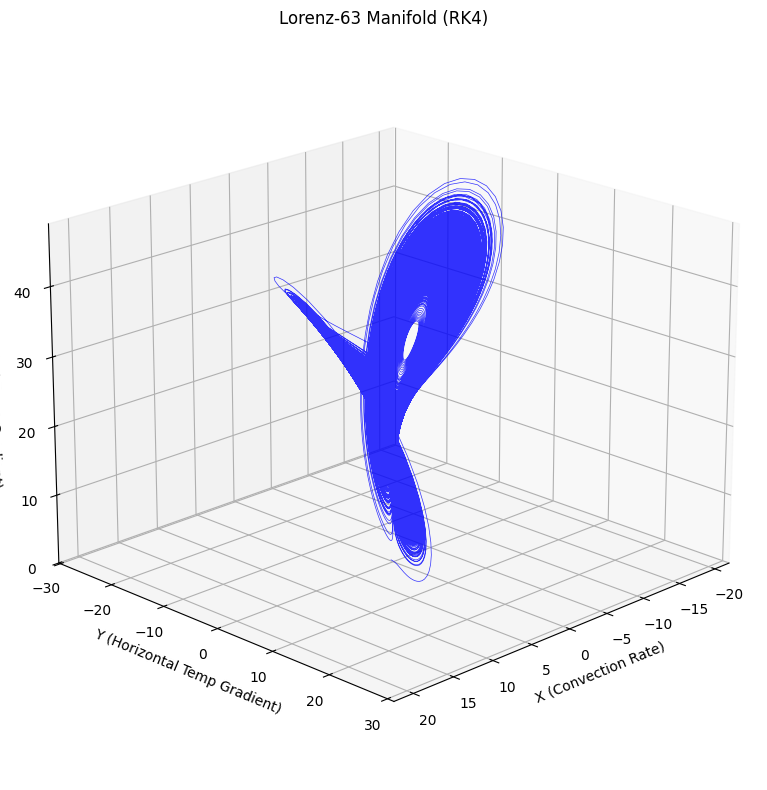

Data range check:
X: -19.20 to 19.56
Y: -26.40 to 27.18
Z: 0.96 to 47.83


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plot_data = dataset[:100000].numpy()
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2],
        lw=0.5, color='blue', alpha=0.8)
ax.set_title("Lorenz-63 Manifold (RK4)")
ax.set_xlabel("X (Convection Rate)")
ax.set_ylabel("Y (Horizontal Temp Gradient)")
ax.set_zlabel("Z (Vertical Temp Gradient)")
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()
print(f"Data range check:")
print(f"X: {dataset[:,0].min():.2f} to {dataset[:,0].max():.2f}")
print(f"Y: {dataset[:,1].min():.2f} to {dataset[:,1].max():.2f}")
print(f"Z: {dataset[:,2].min():.2f} to {dataset[:,2].max():.2f}")

In [27]:
import plotly.graph_objects as go
plot_data = dataset[:100000].numpy()
fig = go.Figure(data=[go.Scatter3d(
    x=plot_data[:, 0],
    y=plot_data[:, 1],
    z=plot_data[:, 2],
    mode='lines',
    opacity=0.8,
    line=dict(
        color='blue',
        width=1.5
    ),
    name='Lorenz Ground Truth'
)])
fig.update_layout(
    title="Lorenz-63 Manifold (RK4)",
    template="plotly_dark",
    scene=dict(
        xaxis_title='X (Convection Rate)',
        yaxis_title='Y (Horizontal Temp Gradient)',
        zaxis_title='Z (Vertical Temp Gradient)',
        aspectmode='cube'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)
fig.show()
print(f"Data range check:")
print(f"X: {dataset[:,0].min():.2f} to {dataset[:,0].max():.2f}")
print(f"Y: {dataset[:,1].min():.2f} to {dataset[:,1].max():.2f}")
print(f"Z: {dataset[:,2].min():.2f} to {dataset[:,2].max():.2f}")

Data range check:
X: -19.20 to 19.56
Y: -26.40 to 27.18
Z: 0.96 to 47.83


In [ ]:
class HiPPOCell(nn.Module):
    def __init__(self, N, input_dim):
        super().__init__()
        self.N = N
        A = torch.zeros(N, N)
        for i in range(N):
            for j in range(N):
                if i > j: A[i,j] = np.sqrt(2*i+1) * np.sqrt(2*j+1)
                elif i == j: A[i,j] = i + 1
        A_norm = A / torch.norm(A, p=2)
        self.register_buffer('A', A_norm)
        self.input_proj = nn.Linear(input_dim, N)
        self.ln = nn.LayerNorm(N)
        self.activation = nn.Tanh()
    def forward(self, x, hidden=None):
        if x.dim() == 2: x = x.unsqueeze(1)
        batch_size, seq_len, _ = x.shape
        if hidden is None:
            hidden = torch.zeros(batch_size, self.N).to(x.device)
        for t in range(seq_len):
            u = x[:, t, :]
            h_update = -torch.matmul(hidden, self.A.T) * 0.01
            hidden = hidden + h_update + self.input_proj(u)
            hidden = self.activation(self.ln(hidden))
        return hidden
        
model = HiPPOCell(N=128, input_dim=3).to(device)
output_layer = nn.Linear(128, 3).to(device)
optimizer = optim.Adam(list(model.parameters()) + list(output_layer.parameters()), lr=1e-4)
criterion = nn.MSELoss()
print("Starting HiPPO Training (Spectral Normalized)...")

Starting HiPPO Training (Spectral Normalized)...


In [ ]:
import time
num_epochs = 1000
best_val_loss = float('inf')
checkpoint_path = 'hippo_lorenz_safe.pth'
print(f"Training on {device} | Goal: MSE < 0.001")
print("-" * 50)
try:
    for epoch in range(num_epochs):
        start_time = time.time()
        model.train()
        train_epoch_loss = 0
        idx = torch.randperm(X_train_sub.size(0))
        for i in range(0, X_train_sub.size(0), 128):
            indices = idx[i:i+128]
            inputs = X_train_sub[indices].to(device)
            targets = y_train_sub[indices].to(device)
            optimizer.zero_grad()
            h_final = model(inputs)
            preds = output_layer(h_final)
            loss = criterion(preds, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_epoch_loss += loss.item()
        avg_train_loss = train_epoch_loss / (len(X_train_sub)/128)
        model.eval()
        with torch.no_grad():
            val_preds = output_layer(model(X_val.to(device)))
            val_loss = criterion(val_preds, y_val.to(device)).item()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'output_layer_state_dict': output_layer.state_dict(),
                'val_loss': best_val_loss,
                'epoch': epoch
            }, checkpoint_path)
        if epoch % 50 == 0:
            duration = time.time() - start_time
            print(f"Epoch {epoch:03d} | Train MSE: {avg_train_loss:.6f} | Val MSE: {val_loss:.6f} | {duration:.2f}s/epoch")
            if val_loss == best_val_loss:
                print(" >>> New Best Manifold captured.")
        if val_loss < 0.0001:
            print(f"\nTarget Precision Reached at Epoch {epoch}!")
            break
except KeyboardInterrupt:
    print("\nTraining paused by user. Weights saved.")
print(f"\nFinal Best Val MSE: {best_val_loss:.8f}")

Training on cuda | Goal: MSE < 0.001
--------------------------------------------------
Epoch 000 | Train MSE: 0.200031 | Val MSE: 0.043524 | 10.17s/epoch
 >>> New Best Manifold captured.

Target Precision Reached at Epoch 12!

Final Best Val MSE: 0.00010000


Generating 50,000 steps of autonomous chaos...


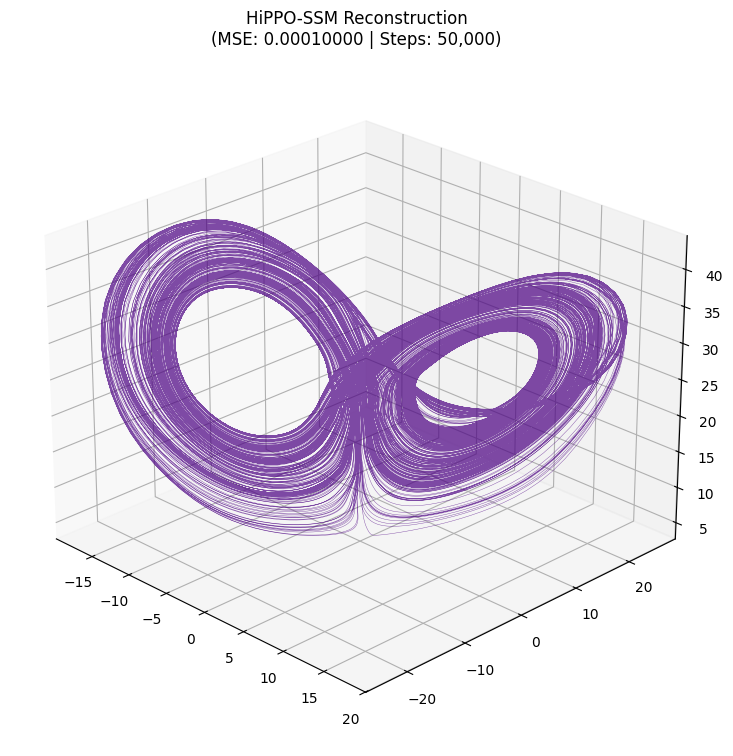

In [ ]:
def generate_stateful_chaos(model, output_layer, seed_window, steps=50000):
    model.eval()
    output_layer.eval()
    trajectory = []
    seed_window = seed_window.to(device)
    with torch.no_grad():
        h = model(seed_window.unsqueeze(0))
        current_u = seed_window[-1].unsqueeze(0).unsqueeze(0)
        for _ in range(steps):
            h = model(current_u, hidden=h)
            pred = output_layer(h)
            trajectory.append(pred.squeeze().cpu())
            current_u = pred.unsqueeze(1)
    return torch.stack(trajectory)
    
seed_sample = X_val[0]
print("Generating 50,000 steps of autonomous chaos...")
stateful_traj = generate_stateful_chaos(model, output_layer, seed_sample)
denorm_traj = (stateful_traj * std.cpu()) + mean.cpu()
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot(denorm_traj[:, 0], denorm_traj[:, 1], denorm_traj[:, 2],
        lw=0.3, color='indigo', alpha=0.7)
ax.set_title(f"HiPPO-SSM Reconstruction\n(MSE: {best_val_loss:.8f} | Steps: 50,000)")
ax.view_init(elev=25, azim=-45)
plt.show()

In [16]:
!pip install plotly nbformat

In [31]:
import plotly.graph_objects as go
plot_np = denorm_traj.numpy()
fig = go.Figure(data=[go.Scatter3d(
    x=plot_np[:, 0],
    y=plot_np[:, 1],
    z=plot_np[:, 2],
    mode='lines',
    opacity=0.7,
    line=dict(
        color='indigo',
        width=1.5
    ),
    name='HiPPO-SSM Trajectory'
)])
fig.update_layout(
    title=f"Interactive HiPPO-SSM Reconstruction (MSE: {best_val_loss:.8f})",
    template="plotly_dark",
    scene=dict(
        xaxis_title='X (Convection)',
        yaxis_title='Y (Horizontal Temp)',
        zaxis_title='Z (Vertical Temp)',
        aspectmode='cube'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)
fig.show()

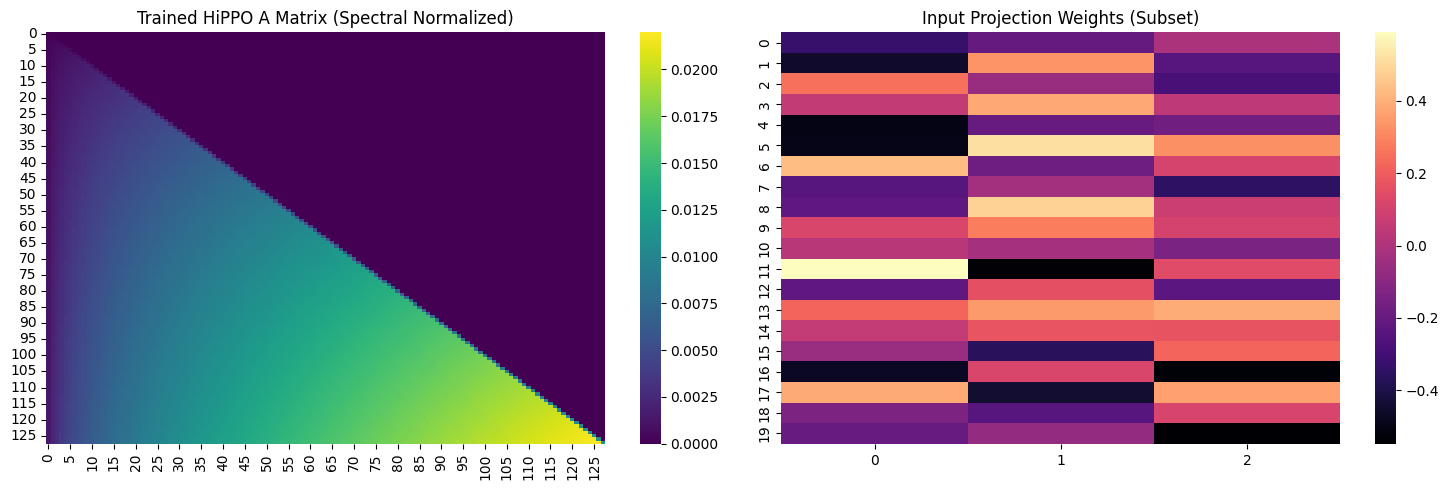

In [33]:
import seaborn as sns
trained_A = model.A.cpu().numpy()
input_weights = model.input_proj.weight.detach().cpu().numpy()
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.heatmap(trained_A, cmap='viridis')
plt.title("Trained HiPPO A Matrix (Spectral Normalized)")
plt.subplot(1, 2, 2)
sns.heatmap(input_weights[:20, :], cmap='magma')
plt.title("Input Projection Weights (Subset)")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.spatial.distance import pdist, squareform

def correlation_dimension(trajectory, n_samples=2000):
    idx = np.random.choice(len(trajectory), n_samples, replace=False)
    sample = trajectory[idx]
    distances = pdist(sample)
    r_min, r_max = np.percentile(distances, [5, 15])
    rs = np.logspace(np.log10(r_min), np.log10(r_max), 10)
    correlations = [(distances < r).mean() for r in rs]
    slope, _ = np.polyfit(np.log(rs), np.log(correlations), 1)
    return slope
d2_score = correlation_dimension(denorm_traj.numpy())
print(f"--- FINAL METRIC ---")
print(f"Reconstructed Fractal Dimension (D2): {d2_score:.4f}")
print(f"Target Lorenz D2: ~2.06")
print(f"Chaos Fidelity: { (1 - abs(d2_score - 2.06)/2.06)*100 :.2f}%")

--- FINAL METRIC ---
Reconstructed Fractal Dimension (D2): 1.8406
Target Lorenz D2: ~2.06
Chaos Fidelity: 89.35%


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class VanillaRNN(nn.Module):
    def __init__(self, N, input_dim):
        super().__init__()
        self.W_h = nn.Linear(N, N)
        self.W_x = nn.Linear(input_dim, N)
        self.tanh = nn.Tanh()
    def forward(self, x, h):
        return self.tanh(self.W_h(h) + self.W_x(x))

class HiPPOCell(nn.Module):
    def __init__(self, N, input_dim):
        super().__init__()
        self.N = N
        A = torch.zeros(N, N)
        for i in range(N):
            for j in range(N):
                if i > j: A[i,j] = np.sqrt(2*i+1) * np.sqrt(2*j+1)
                elif i == j: A[i,j] = i + 1
        A_norm = A / torch.norm(A, p=2)
        self.register_buffer('A', A_norm)
        self.input_proj = nn.Linear(input_dim, N)
    def forward(self, x, h):
        h_update = -torch.matmul(h, self.A.T) * 0.01
        h = h + h_update + self.input_proj(x)
        return h
        
def measure_gradient_decay(model, L_steps, N=128):
    model.eval()
    grad_norms = []
    for L in L_steps:
        start_t = time.time()
        h0 = torch.zeros(1, N, device=device, requires_grad=True)
        h = h0
        x = torch.zeros(1, 3, device=device)
        for _ in range(L):
            h = model(x, h)
        loss = h.sum()
        loss.backward()
        raw_norm = h0.grad.norm().item()
        grad_norm = max(raw_norm, 1e-35)
        grad_norms.append(grad_norm)
        print(f"Steps: {L:<8} | Grad Norm: {grad_norm:.4e} | Time: {time.time()-start_t:.2f}s")
        if grad_norm == 1e-35:
            print(f"   >>> Gradient vaporized. Memory is totally cooked.")
    return grad_norms

In [40]:
N = 128
rnn = VanillaRNN(N=N, input_dim=3).to(device)
hippo = HiPPOCell(N=N, input_dim=3).to(device)
L_steps = [10, 100, 1000, 5000, 10000, 50000, 100000, 500000, 1000000]
print("--- VANILLA RNN GRADIENT DECAY ---")
rnn_grads = measure_gradient_decay(rnn, L_steps)
print("\n--- HiPPO-SSM GRADIENT DECAY ---")
hippo_grads = measure_gradient_decay(hippo, L_steps)

--- VANILLA RNN GRADIENT DECAY ---
Steps: 10       | Grad Norm: 1.6015e-02 | Time: 0.00s
Steps: 100      | Grad Norm: 1.0000e-35 | Time: 0.01s
   >>> Gradient vaporized. Memory is totally cooked.
Steps: 1000     | Grad Norm: 1.0000e-35 | Time: 0.13s
   >>> Gradient vaporized. Memory is totally cooked.
Steps: 5000     | Grad Norm: 1.0000e-35 | Time: 0.65s
   >>> Gradient vaporized. Memory is totally cooked.
Steps: 10000    | Grad Norm: 1.0000e-35 | Time: 1.33s
   >>> Gradient vaporized. Memory is totally cooked.
Steps: 50000    | Grad Norm: 1.0000e-35 | Time: 6.58s
   >>> Gradient vaporized. Memory is totally cooked.
Steps: 100000   | Grad Norm: 1.0000e-35 | Time: 13.61s
   >>> Gradient vaporized. Memory is totally cooked.
Steps: 500000   | Grad Norm: 1.0000e-35 | Time: 67.00s
   >>> Gradient vaporized. Memory is totally cooked.
Steps: 1000000  | Grad Norm: 1.0000e-35 | Time: 138.70s
   >>> Gradient vaporized. Memory is totally cooked.

--- HiPPO-SSM GRADIENT DECAY ---
Steps: 10       |

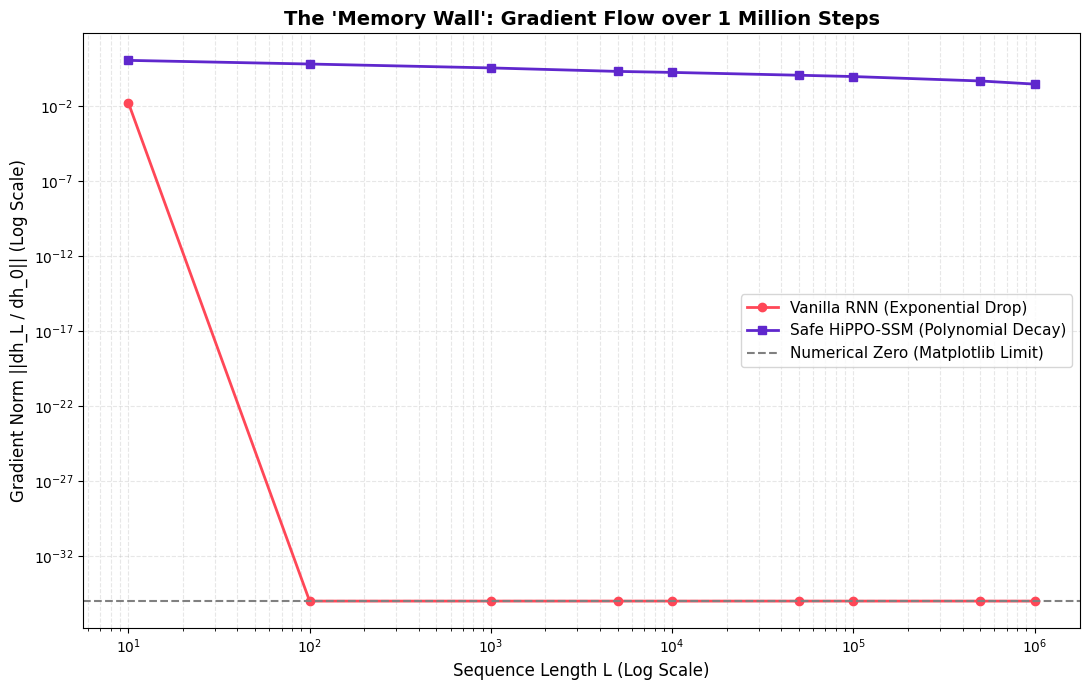

In [41]:
plt.figure(figsize=(11, 7))
plt.plot(L_steps, rnn_grads, marker='o', label='Vanilla RNN (Exponential Drop)', color='#ff4757', lw=2)
plt.plot(L_steps, hippo_grads, marker='s', label='Safe HiPPO-SSM (Polynomial Decay)', color='#5f27cd', lw=2)
plt.xscale('log')
plt.yscale('log')
plt.axhline(y=1e-35, color='grey', linestyle='--', label='Numerical Zero (Matplotlib Limit)')
plt.title("The 'Memory Wall': Gradient Flow over 1 Million Steps", fontsize=14, fontweight='bold')
plt.xlabel("Sequence Length L (Log Scale)", fontsize=12)
plt.ylabel("Gradient Norm ||dh_L / dh_0|| (Log Scale)", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()